::: {.callout-note appearance="minimal" icon=false}
Language: **Python** (Jupyter notebook) - [R version](r.qmd)
:::

Ported from
[`bayesian_regression.py`](https://github.com/USACE-RMC/Numerics-Python-Examples/blob/main/examples/bayesian_regression.py)
in the USACE-RMC Numerics-Python-Examples repository (0BSD licensed). The upstream
script drives the C# `Numerics.dll` through pythonnet, handing the `DEMCzs` sampler a
list of hand-picked `Uniform` priors and a Python log-likelihood callback. That
callback-likelihood pattern is deliberately not exposed by `corehydropy`, so this
version recasts the same regression through `arimax_analysis` (details below) and the
reproduction is statistical rather than exact. The synthetic data, however, are
bit-identical to the upstream script's, and the R version of this example uses the
same core and prints the same numbers.

## What you'll learn

- How to regenerate the upstream script's synthetic data exactly (same seeded
  Mersenne Twister).
- How to express a Bayesian linear regression as an ARIMAX(0,0,0) model with a
  linear time trend.
- What the returned curves are: the MAP fitted line and a posterior predictive band.

## Synthetic data

The upstream script simulates a straight line with Normal noise:
`x = linspace(0, 10, 80)` and `y = a + b*x + Normal(0, sigma)` with
`a = 2.0`, `b = 1.4`, `sigma = 1.2`, drawing the noise with seed 123. The port
keeps the C# Mersenne Twister bit-exact, so `Distribution("Normal", ...).random`
with the same seed reproduces the upstream noise vector to the last bit. We write
`x` as `10*t/79` for the time index `t = 0..79`, which is the same array as
`linspace(0, 10, 80)` and makes the mapping used below explicit.

One quirk worth knowing about, since the upstream run sees the identical draw: this
particular seeded noise vector runs light. Its sample standard deviation is 0.904,
well under the nominal 1.2, so any faithful posterior for `sigma` concentrates near
0.9.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corehydropy as ch

n = 80
true_a, true_b, true_sigma = 2.0, 1.4, 1.2

t = np.arange(n)        # time index 0..79
x = 10.0 * t / 79.0     # identical to np.linspace(0, 10, 80)

noise = np.asarray(ch.Distribution("Normal", [0.0, true_sigma]).random(n, seed=123))
y = true_a + true_b * x + noise

print(f"first observations: {y[:4]}")
print(f"realized noise sd: {noise.std(ddof=1):.4f} (nominal {true_sigma})")

first observations: [2.61712676 2.85166215 1.67679187 2.31532347]
realized noise sd: 0.9037 (nominal 1.2)


## Recasting the regression

The upstream script builds a C# `List` of three priors (`Uniform(-10, 10)` for `a`,
`Uniform(0, 5)` for `b`, `Uniform(0.1, 5)` for `sigma`) and a Python callback that
sums `Normal(0, sigma).LogPDF(residual)` over the data. Neither custom priors nor
likelihood callbacks are part of the public API here. But regression on the time
index is a built-in model: `arimax_analysis` with orders `p = d = q = 0`, an
intercept, and `trend="Linear"` fits

$$y_t = \mu + \gamma t + \varepsilon_t, \qquad \varepsilon_t \sim \text{Normal}(0, \sigma),$$

which is Bayesian simple linear regression, sampled with the same DEMCzs sampler
the upstream uses. Because `x = 10t/79` is an affine map of the time index, the
upstream parameters translate directly:

- intercept: $a = \mu$, so the true value is 2.0;
- slope: $\gamma = b \cdot 10/79$, so the true trend per time step is
  $1.4 \cdot 10/79 = 0.17722$, and the fitted slope maps back as
  $b = \gamma \cdot 79/10$;
- `sigma` is the residual standard deviation in both parameterizations.

Two honest differences from the upstream run. First, the priors are the model's own
data-scaled uniforms (order-of-magnitude bounds built around a least-squares
initialization), not the upstream's hand-picked ones, so posterior numbers can only
be compared statistically. Second, the runtime: the upstream script takes about five
minutes because every likelihood evaluation crosses back into Python; here the
likelihood is compiled, and the modest settings below finish in about a second.

`parameters` in the returned dict is the posterior mode (MAP) vector, in model
order: intercept $\mu$, trend $\gamma$, then $\sigma$ last.

In [2]:
fit = ch.arimax_analysis(
    y,
    order_p=0, order_d=0, order_q=0,  # no AR, differencing, or MA terms
    trend="Linear",                   # deterministic trend gamma * t
    include_intercept=True,           # intercept mu
    training_time_steps=n,            # fit on all 80 points
    forecasting_time_steps=0,
    sampler="DEMCzs",                 # the sampler the upstream script uses
    iterations=2000,
    output_length=5000,
    credible_level=0.90,
    seed=45678,
)

mu_map, gamma_map, sigma_map = fit["parameters"]
b_map = gamma_map * 79.0 / 10.0  # slope per time step -> slope per unit x

summary = pd.DataFrame({
    "parameter": ["intercept a", "slope b", "slope per step gamma", "sigma"],
    "truth": [true_a, true_b, true_b * 10.0 / 79.0, true_sigma],
    "MAP": [mu_map, b_map, gamma_map, sigma_map],
})
print(summary.to_string(index=False))
print(f"\nrmse: {fit['rmse']:.4f}")

           parameter    truth      MAP
         intercept a 2.000000 2.043677
             slope b 1.400000 1.391644
slope per step gamma 0.177215 0.176157
               sigma 1.200000 0.918454

rmse: 0.8977


All three parameters land close to the generating values, with `sigma` tracking
the realized noise level (0.904) rather than the nominal 1.2, exactly as the
upstream run does with the same data.

## Fitted line and band

What the returned curves are, since they differ from the upstream plot:

- `mode_curve` is the deterministic fitted line $\mu + \gamma t$ evaluated at the
  MAP parameters.
- `mean_curve`, `lower_ci`, and `upper_ci` come from a posterior predictive
  ensemble: each posterior draw simulates a full series including observation
  noise. The 90% band is therefore a predictive band for observations, wider than
  the mean-function credible band the upstream script plots.

The upstream 2x2 figure also shows posterior histograms of `a`, `b`, and `sigma`;
the analysis returns curves and MAP values rather than raw chains, so those two
panels cannot be reproduced here.

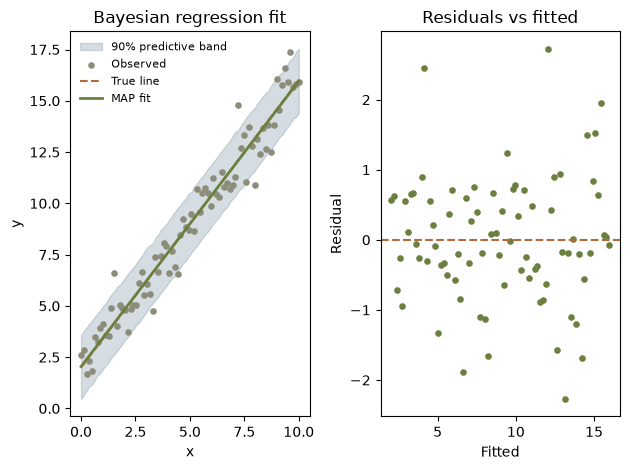

In [3]:
mode_curve = np.asarray(fit["mode_curve"])
lower = np.asarray(fit["lower_ci"])
upper = np.asarray(fit["upper_ci"])
true_line = true_a + true_b * x

fig, axes = plt.subplots(1, 2)

axes[0].fill_between(x, lower, upper, color="#5b7a8c", alpha=0.25,
                     label="90% predictive band")
axes[0].scatter(x, y, color="#8c8c7a", s=14, label="Observed")
axes[0].plot(x, true_line, color="#b06a3b", linestyle="--", linewidth=1.5,
             label="True line")
axes[0].plot(x, mode_curve, color="#6b7f3f", linewidth=2, label="MAP fit")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Bayesian regression fit")
axes[0].legend(frameon=False, fontsize=8)

residuals = y - mode_curve
axes[1].scatter(mode_curve, residuals, color="#6b7f3f", s=14)
axes[1].axhline(0, color="#b06a3b", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Fitted")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs fitted")

fig.tight_layout()
plt.show()

In [4]:
inside = (y >= lower) & (y <= upper)
covers_true = (true_line >= lower) & (true_line <= upper)
print(f"observations inside the 90% predictive band: {inside.mean():.4f}")
print(f"ordinates where the band covers the true line: {covers_true.sum()} of {n}")

observations inside the 90% predictive band: 0.8875
ordinates where the band covers the true line: 80 of 80


## Reproduction check

The upstream file is a script with no committed outputs, so there are no upstream
posterior literals to compare against; the reference values are the true generating
parameters. The priors and the parameterization deliberately differ (data-scaled
uniform priors, time-index trend), so bit-comparison with the upstream posterior is
impossible and the parameter checks are statistical. The exact tier covers what is
exactly checkable: the seeded synthetic data (the same Mersenne Twister stream the
upstream draws) and cross-language identity of the whole analysis (the R twin
asserts the same MAP literals from the same seed).

| Quantity | Upstream C# | This port | Status |
|----------|------------:|----------:|--------|
| Seeded data `y[0]` (seed 123) | same MT stream | 2.61712675977869 | exact |
| Seeded data `y[79]` | same MT stream | 15.89237584375904 | exact |
| Intercept `a` | 2.0 (true) | MAP 2.0437 | statistical |
| Slope `b` | 1.4 (true) | MAP 1.3916 | statistical |
| `sigma` | 1.2 nominal, 0.9037 realized | MAP 0.9185 | statistical |
| 90% band covers the true line | - | 80 of 80 ordinates | statistical |

The cell below fails the notebook if any value drifts.

In [5]:
# Upstream: examples/bayesian_regression.py (a script with no committed outputs;
# the reference values are the true generating parameters, not upstream posteriors).

# Exact: the seeded synthetic data, identical across Python, R, and the C# library.
assert y[0] == 2.6171267597786905
assert y[-1] == 15.892375843759043

# Exact: cross-language identity of the fit itself (same seed, same core; the R twin
# asserts these same literals).
assert mu_map == 2.043676501381344
assert gamma_map == 0.1761574955229039

# Statistical: recovered parameters near the truth. Priors and parameterization
# deliberately differ from the upstream script, so only closeness can be asserted.
assert abs(mu_map - true_a) < 0.5
assert abs(b_map - true_b) < 0.1
assert 0.7 < sigma_map < 1.2  # tracks the realized noise sd, 0.9037

# Statistical: the 90% predictive band covers the true line everywhere and most
# observations.
assert covers_true.all()
assert inside.mean() > 0.8
print("All reproduction checks passed.")

All reproduction checks passed.
